In [34]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager
font_dirs = ["/content/drive/MyDrive/NU work/Font"]  # The path to the custom font file./content/Arial.ttf
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

print(font_files)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
font_manager.get_font_names()


plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 8
plt.rcParams['hatch.linewidth'] = 0.5

['/content/drive/MyDrive/NU work/Font/Arial Bold Italic.ttf', '/content/drive/MyDrive/NU work/Font/Arial.ttf', '/content/drive/MyDrive/NU work/Font/Arial Italic.ttf', '/content/drive/MyDrive/NU work/Font/Arial Bold.ttf']


In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def read_excel_data(filepath, sheet_name):
    """Read LCA data from Excel file and split scenarios"""
    df = pd.read_excel(filepath, sheet_name=sheet_name)

    # Clean column names
    columns = {
        'Herbicides (kg CO2/1000kg lint)': 'Herbicides',
        'Insecticides (kg CO2/1000kg lint)': 'Insecticides',
        'Phosphoric Acid (kg CO2/1000kg lint)': 'Phosphoric Acid',
        'Potassium Oxide (kg CO2/1000kg lint)': 'Potassium Oxide',
        'Calcium Carbonate (kg CO2/1000kg lint)': 'Calcium Carbonate',
        'N Fertilizer (kg CO2/1000kg lint)': 'N Fertilizer Production',
        'Diesel (kg CO2/1000kg lint)': 'Diesel',
        'N2O Emission (kg CO2/1000kg lint)': 'N2O Emission',
        'Irrigation Water (kg CO2/1000kg lint)_year 2023 surveyed': 'Irrigation Water',
        'Electricity (kg CO2 /1000 kg cotton lint)': 'Electricity'
    }
    clean_names = ['State', 'Herbicides', 'Insecticides', 'Phosphoric Acid',
               'Potassium Oxide', 'Calcium Carbonate', 'N Fertilizer Production',
               'Diesel', 'N₂O Emission', 'Irrigation Water', 'Electricity']

    df.columns = clean_names

    # Find pro-electricity separator
    for idx, row in df.iterrows():
        if pd.notna(row.iloc[0]) and 'pro-electricity' in str(row.iloc[0]).lower():
            split_idx = idx + 1
            break

    # Split scenarios
    base_df = df.iloc[:split_idx-2].dropna(subset=['State']).reset_index(drop=True)
    pro_elec_df = df.iloc[split_idx+1:].dropna(subset=['State']).reset_index(drop=True)

    return base_df, pro_elec_df



             State Herbicides Insecticides Phosphoric Acid Potassium Oxide  \
0          Alabama    77.6967        5.852          45.816         23.8793   
1          Arizona    35.2944        3.762          11.546          0.3441   
2         Arkansas    61.7652        25.08          36.777         18.8046   
3       California    31.1277        9.823           4.807          2.6257   
4          Florida     95.589        14.63          35.604         12.8619   
5          Georgia    68.1378         6.27          51.221         24.2575   
6           Kansas     95.589        14.63          35.604         12.8619   
7        Louisiana    93.6282       30.514          39.284         17.2546   
8      Mississippi    80.6379        29.26          22.977          17.732   
9         Missouri    51.7161       19.019           34.04         15.1559   
10      New Mexico     95.589        14.63          35.604         12.8619   
11  North Carolina     80.883       11.913          25.208      

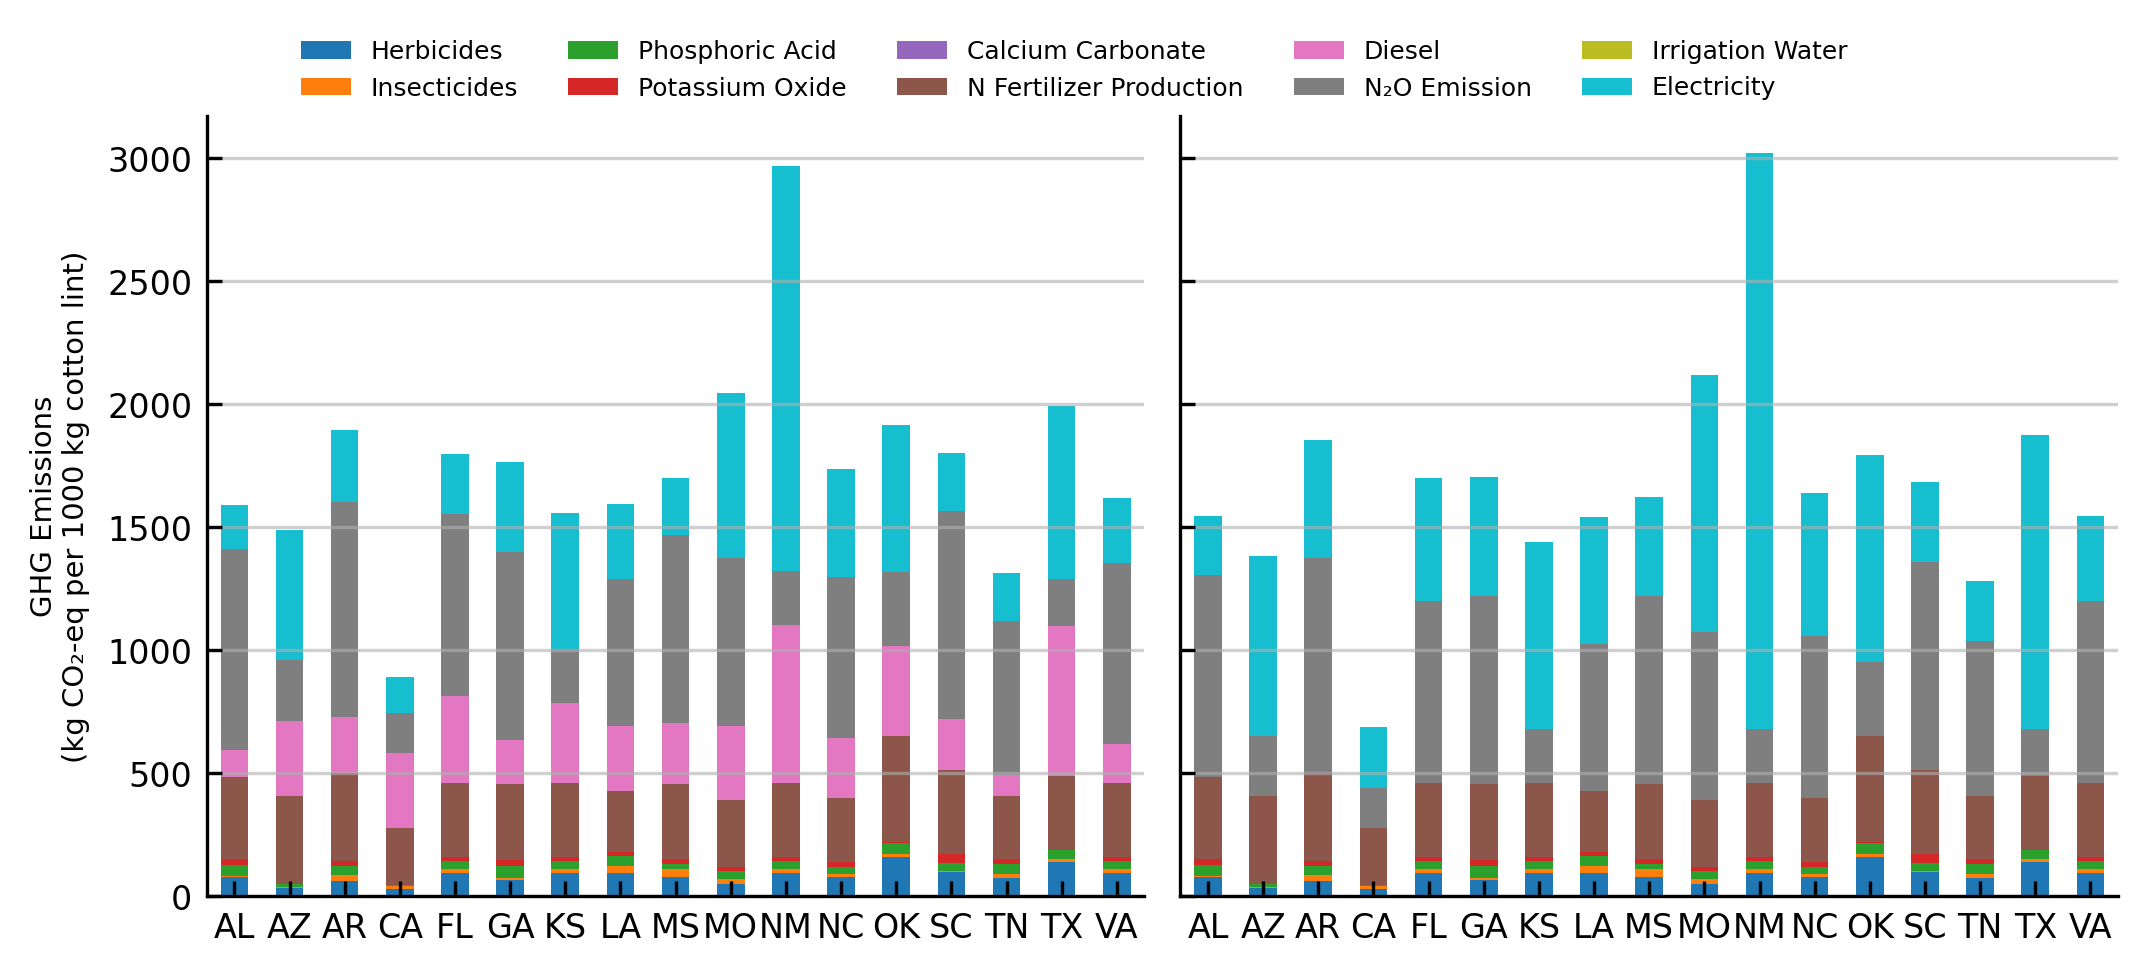

In [56]:
abbrev_list = ['AL', 'AZ', 'AR', 'CA', 'FL', 'GA', 'KS', 'LA', 'MS', 'MO', 'NM', 'NC', 'OK', 'SC', 'TN', 'TX', 'VA']

base_df, pro_elec_df = read_excel_data('/content/drive/MyDrive/NU work/Cotton/cotton_github/results/Cotton_LCA_17_States.xlsx',
                                       sheet_name='Results_GHG_Breakdown')
print(base_df)
print(pro_elec_df)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 3), sharey=True)

# Plot first DataFrame (no legend)
base_df.plot(kind='bar', stacked=True, ax=ax1, legend=False)
ax1.grid(True, axis='y', alpha=0.6)
# Plot second DataFrame (no legend)
pro_elec_df.plot(kind='bar', stacked=True, ax=ax2, legend=False)
ax2.grid(True, axis='y', alpha=0.6)
# Create shared legend at the top center
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(0.5, 1.07), loc='upper center', ncol=5,
           frameon=False,
           fontsize=6)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xticklabels(abbrev_list, rotation=0, ha='center')

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xticklabels(abbrev_list, rotation=0, ha='center')
ax1.set_ylabel('GHG Emissions\n(kg CO₂-eq per 1000 kg cotton lint)', fontsize=7)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/lca_state_GHG_results.tiff', dpi=300, bbox_inches='tight')
plt.show()

             State Herbicides Insecticides Phosphoric Acid Potassium Oxide  \
0          Alabama    1252.15        85.96          677.28        549.2239   
1          Arizona      568.8        55.26          170.68          7.9143   
2         Arkansas      995.4        368.4          543.66        432.5058   
3       California     501.65       144.29           71.06         60.3911   
4          Florida     1540.5        214.9          526.32        295.8237   
5          Georgia     1098.1         92.1          757.18        557.9225   
6           Kansas     1540.5        214.9          526.32        295.8237   
7        Louisiana     1508.9       448.22          580.72        396.8558   
8      Mississippi    1299.55        429.8          339.66         407.836   
9         Missouri     833.45       279.37           503.2        348.5857   
10      New Mexico     1540.5        214.9          526.32        295.8237   
11  North Carolina     1303.5       174.99          372.64      

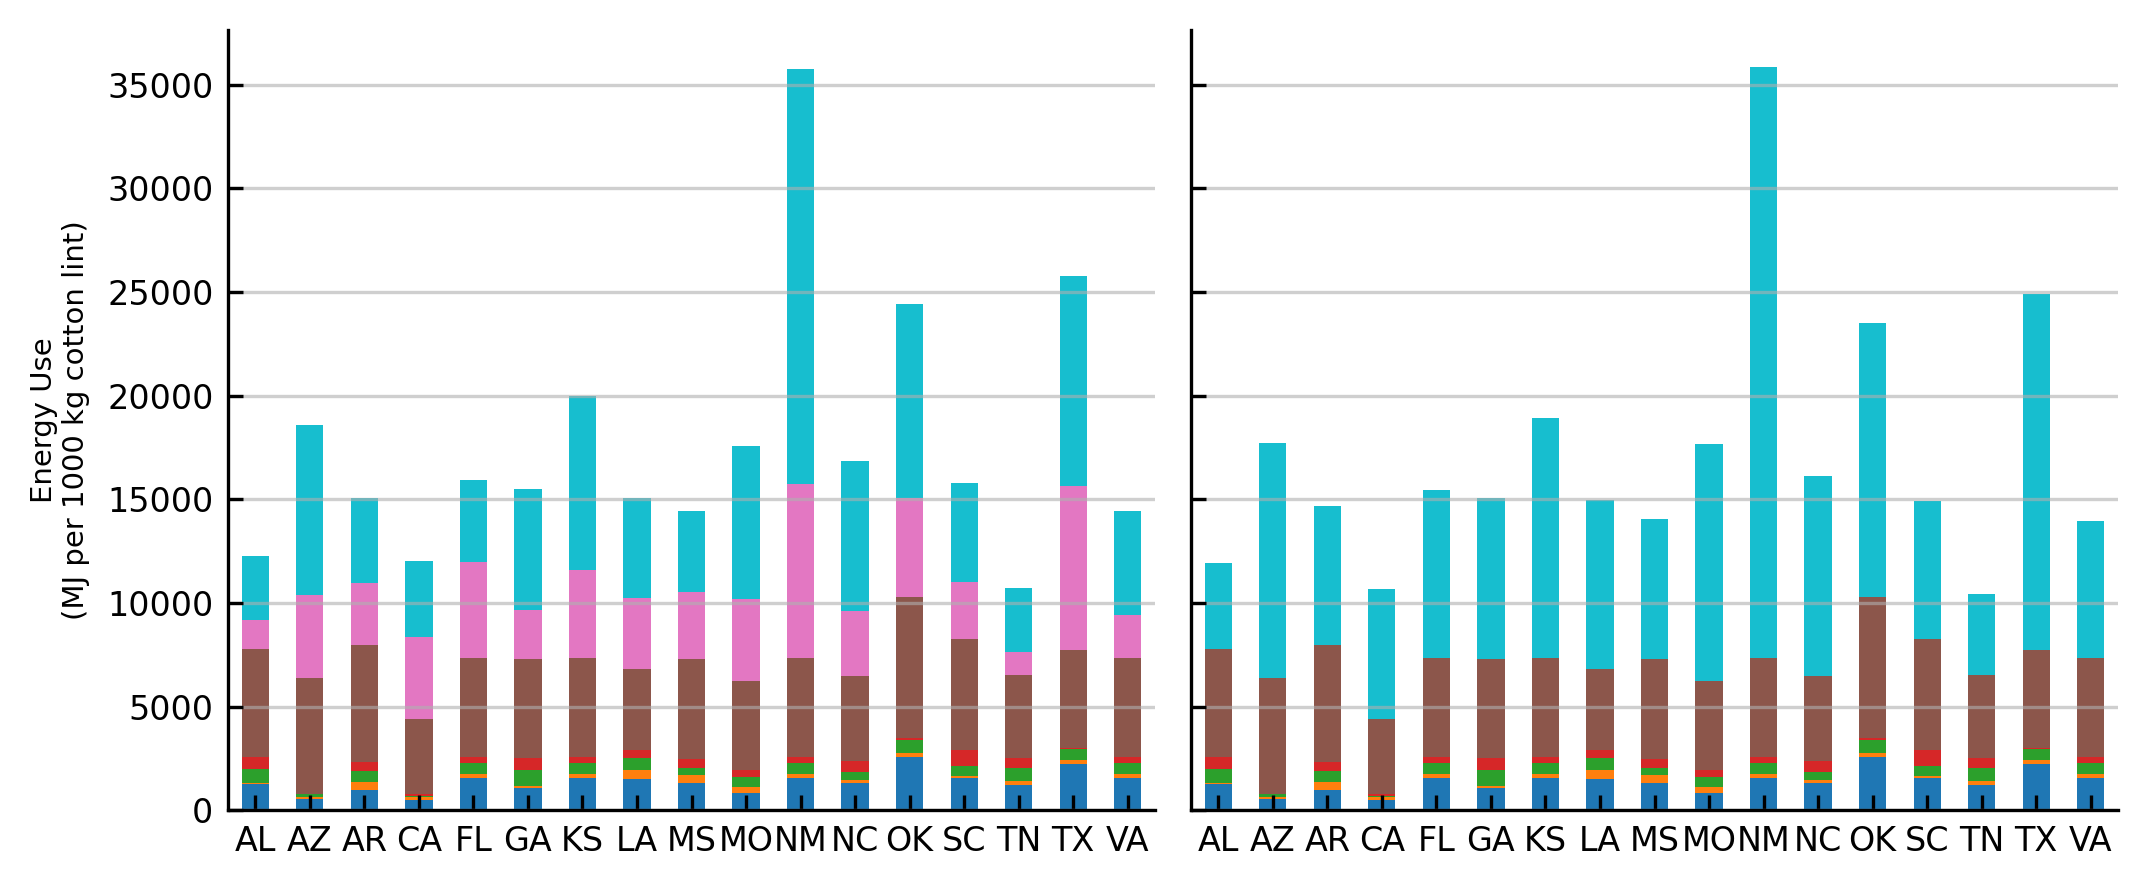

In [58]:
abbrev_list = ['AL', 'AZ', 'AR', 'CA', 'FL', 'GA', 'KS', 'LA', 'MS', 'MO', 'NM', 'NC', 'OK', 'SC', 'TN', 'TX', 'VA']

base_df, pro_elec_df = read_excel_data('/content/drive/MyDrive/NU work/Cotton/cotton_github/results/Cotton_LCA_17_States.xlsx',
                                       sheet_name='Results_Energy_Breakdown')
print(base_df)
print(pro_elec_df)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 3), sharey=True)

# Plot first DataFrame (no legend)
base_df.plot(kind='bar', stacked=True, ax=ax1, legend=False)
ax1.grid(True, axis='y', alpha=0.6)
# Plot second DataFrame (no legend)
pro_elec_df.plot(kind='bar', stacked=True, ax=ax2, legend=False)
ax2.grid(True, axis='y', alpha=0.6)
# Create shared legend at the top center
# handles, labels = ax1.get_legend_handles_labels()
# fig.legend(handles, labels, bbox_to_anchor=(0.5, 1.07), loc='upper center', ncol=5,
#            frameon=False,
#            fontsize=6)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xticklabels(abbrev_list, rotation=0, ha='center')

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xticklabels(abbrev_list, rotation=0, ha='center')
ax1.set_ylabel('Energy Use\n(MJ per 1000 kg cotton lint)', fontsize=7)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/lca_state_Energy_results.tiff', dpi=300, bbox_inches='tight')
plt.show()

             State Herbicides Insecticides Phosphoric Acid Potassium Oxide  \
0          Alabama   214.7358      10.8948       1466.5104        761.8267   
1          Arizona    97.5456       7.0038        369.5724         10.9779   
2         Arkansas   170.7048       46.692       1177.1838        599.9274   
3       California    86.0298      18.2877        153.8658         83.7683   
4          Florida    264.186       27.237       1139.6376        410.3361   
5          Georgia   188.3172       11.673       1639.5174        773.8925   
6           Kansas    264.186       27.237       1139.6376        410.3361   
7        Louisiana   258.7668      56.8086       1257.4296        550.4774   
8      Mississippi   222.8646       54.474        735.4638         565.708   
9         Missouri   142.9314      35.4081        1089.576        483.5221   
10      New Mexico    264.186       27.237       1139.6376        410.3361   
11  North Carolina    223.542      22.1787        806.8752      

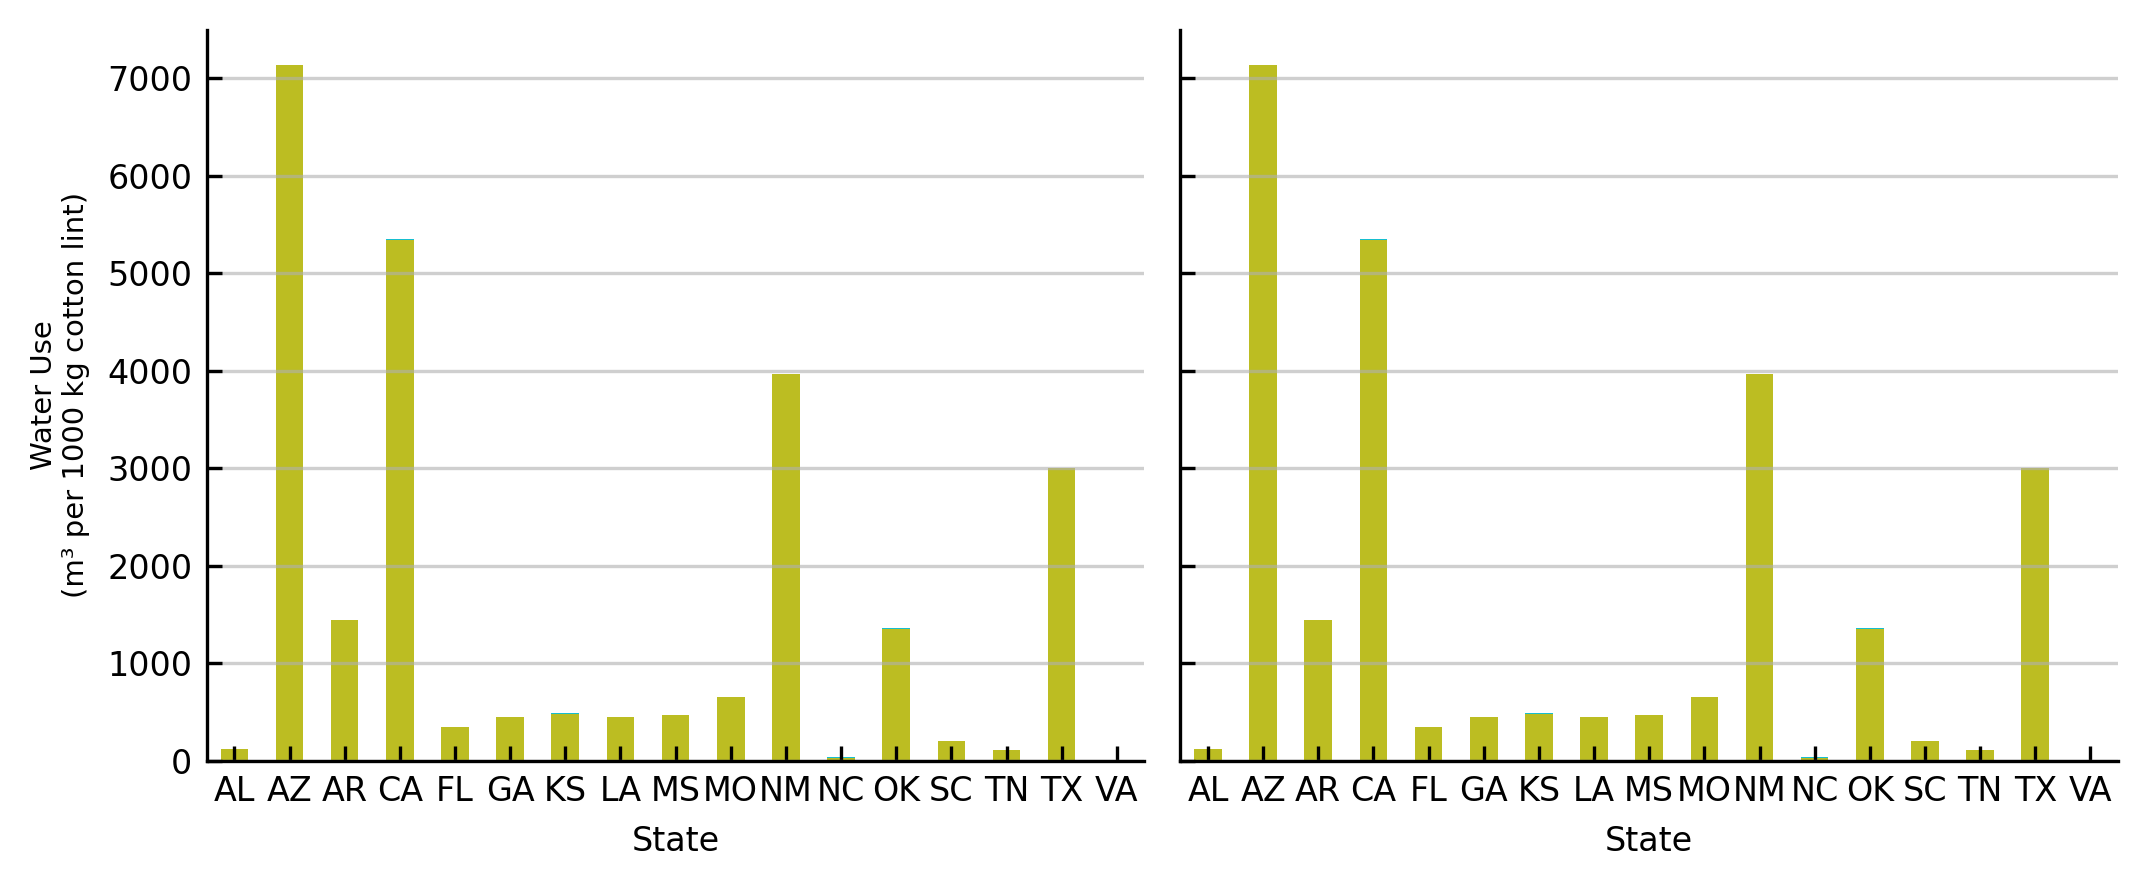

In [63]:
abbrev_list = ['AL', 'AZ', 'AR', 'CA', 'FL', 'GA', 'KS', 'LA', 'MS', 'MO', 'NM', 'NC', 'OK', 'SC', 'TN', 'TX', 'VA']

base_df, pro_elec_df = read_excel_data('/content/drive/MyDrive/NU work/Cotton/cotton_github/results/Cotton_LCA_17_States.xlsx',
                                       sheet_name='Results_Water_Breakdown')
print(base_df)
print(pro_elec_df)

# convert L to m3 - only numeric columns
base_df = base_df.set_index('State')
pro_elec_df = pro_elec_df.set_index('State')

base_df = base_df / 1000
pro_elec_df = pro_elec_df / 1000

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 3), sharey=True)

# Plot first DataFrame (no legend)
base_df.plot(kind='bar', stacked=True, ax=ax1, legend=False)
ax1.grid(True, axis='y', alpha=0.6)

# Plot second DataFrame (no legend)
pro_elec_df.plot(kind='bar', stacked=True, ax=ax2, legend=False)
ax2.grid(True, axis='y', alpha=0.6)

# Remove spines and set labels
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticklabels(abbrev_list, rotation=0, ha='center')

ax1.set_ylabel('Water Use\n(m³ per 1000 kg cotton lint)', fontsize=7)
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/lca_state_Water_results.tiff', dpi=300, bbox_inches='tight')
plt.show()